<a href="https://colab.research.google.com/github/Jabbiks/ML/blob/main/%D0%9B%D0%912_%D0%9C%D0%9D_%D0%90%D0%B2%D1%80%D0%B0%D0%BC%D0%B5%D0%BD%D0%BA%D0%BE_3_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Авраменко ФІТ 3-10

---



In [1]:
import numpy as np
import pandas as pd
import requests

# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [4]:
import io
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}
response = requests.get(url, headers=headers)

tables = pd.read_html(io.StringIO(response.text), match="Country")
df = tables[0]

In [5]:
df.head()

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [7]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[Id+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [19]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
...,...,...,...,...,...
217,Palau,377.0,345.0,310.0,32.0
218,Marshall Islands,342.0,308.0,281.0,34.0
219,Nauru,196.0,176.0,187.0,20.0
220,Montserrat,NaN,NaN,81.0,NaN


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [20]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
...,...,...,...,...,...
217,Palau,377.0,345.0,310.0,32.0
218,Marshall Islands,342.0,308.0,281.0,34.0
219,Nauru,196.0,176.0,187.0,20.0
220,Montserrat,NaN,NaN,81.0,NaN


In [21]:
df.isnull().sum()

,0
Country,0
IMF (2026)[1],31
World Bank (2025)[6],35
United Nations (2024)[7],9
IMF_WB_Diff,39


In [22]:
df['IMF (2026)[1]'] = pd.to_numeric(df['IMF (2026)[1]'], errors='coerce')
df['World Bank (2025)[6]'] = pd.to_numeric(df['World Bank (2025)[6]'], errors='coerce')
df['United Nations (2024)[7]'] = pd.to_numeric(df['United Nations (2024)[7]'], errors='coerce')

In [23]:
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
...,...,...,...,...,...
217,Palau,377.0,345.0,310.0,32.0
218,Marshall Islands,342.0,308.0,281.0,34.0
219,Nauru,196.0,176.0,187.0,20.0
220,Montserrat,NaN,NaN,81.0,NaN


In [24]:
df.isnull().sum()

,0
Country,0
IMF (2026)[1],31
World Bank (2025)[6],35
United Nations (2024)[7],9
IMF_WB_Diff,39


5. Ще раз вивести датасет

In [25]:
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
...,...,...,...,...,...
217,Palau,377.0,345.0,310.0,32.0
218,Marshall Islands,342.0,308.0,281.0,34.0
219,Nauru,196.0,176.0,187.0,20.0
220,Montserrat,NaN,NaN,81.0,NaN


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [26]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [27]:
df.describe()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff
count,1.900000e+02,1.860000e+02,2.120000e+02,1.820000e+02
mean,6.614603e+05,6.260497e+05,5.224912e+05,4.615720e+04
std,2.877162e+06,2.748494e+06,2.460942e+06,1.655103e+05
min,6.500000e+01,5.700000e+01,5.600000e+01,1.000000e+00
25%,1.497975e+04,1.534950e+04,8.480250e+03,9.685000e+02
50%,5.395700e+04,5.166400e+04,3.690450e+04,4.674500e+03
75%,3.547592e+05,3.143390e+05,2.533492e+05,3.016975e+04
max,3.238392e+07,3.076970e+07,2.929800e+07,1.614220e+06


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [28]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)[1]'] - df['World Bank (2025)[6]'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'(country) has the largest difference between IMF and WB: (max_diff)')

df.head(10)

(country) has the largest difference between IMF and WB: (max_diff)


,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [29]:
cor_IMF_WB = df['IMF (2026)[1]'].corr(df['World Bank (2025)[6]'])
cor_IMF_UN = df['IMF (2026)[1]'].corr(df['United Nations (2024)[7]'])
cor_WB_UN = df['World Bank (2025)[6]'].corr(df['United Nations (2024)[7]'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998791099756854
Correlation between IMF and UN: 0.9998224877012787
Correlation between WB and UN: 0.9998611199110091


In [30]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
  print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
  print('IMF and UN have the highest correlation')
else:
  print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [31]:
mean_IMF = df['IMF (2026)[1]'].mean()
mean_IMF

np.float64(661460.2894736842)

In [32]:
mean_WB = df['World Bank (2025)[6]']
mean_WB

,World Bank (2025)[6]
1,30769700.0
2,19498039.0
3,5050923.0
4,4435163.0
5,4002588.0
...,...
217,345.0
218,308.0
219,176.0
220,NaN


In [33]:
mean_UN = df['United Nations (2024)[7]']
mean_UN

,United Nations (2024)[7]
1,29298000.0
2,18743802.0
3,4659929.0
4,4026211.0
5,3685881.0
...,...
217,310.0
218,281.0
219,187.0
220,81.0


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [34]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

United States has the highest standard deviation: 14655779.964896671


,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [35]:
max_IMF = df['IMF (2026)[1]'].max(); min_IMF = df['IMF (2026)[1]'].min()
max_WB = df['World Bank (2025)[6]'].max(); min_WB = df['World Bank (2025)[6]'].min()
max_UN = df['United Nations (2024)[7]'].max(); min_UN = df['United Nations (2024)[7]'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

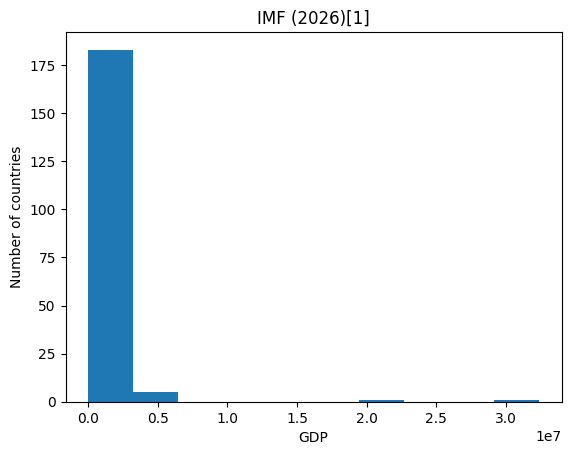

In [36]:
import matplotlib.pyplot as plt

# Build a histogram of IMF_Forecast
plt.hist(df['IMF (2026)[1]'], bins=10)
plt.title('IMF (2026)[1]')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [37]:
df['IMF_Share'] = df['IMF (2026)[1]'] / df['IMF (2026)[1]'].sum()
df['WB_Share'] = df['World Bank (2025)[6]'] / df['World Bank (2025)[6]'].sum()
df['UN_Share'] = df['United Nations (2024)[7]'] / df['United Nations (2024)[7]'].sum()

df.head(10)

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.257675,0.264242,0.264498
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.165914,0.167444,0.169217
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.043388,0.043376,0.042069
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.034845,0.038088,0.036348
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.033934,0.034373,0.033276
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.033046,0.033974,0.035680
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.028614,0.028909,0.028532
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.021787,0.021912,0.021494
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.021137,0.021996,0.019621
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.020974,0.019579,0.019733


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [38]:
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10= df.nlargest(10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.257675,0.264242,0.264498,0.006824
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.165914,0.167444,0.169217,0.003303
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.033046,0.033974,0.035680,0.002634
53,Iran,300293.0,362682.0,448092.0,62389.0,1.654723e+05,0.002389,0.003115,0.004045,0.001656
15,South Korea,1931008.0,1872375.0,1875388.0,58633.0,9.175414e+05,0.015365,0.016079,0.016931,0.001566
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.021137,0.021996,0.019621,0.001516
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.034845,0.038088,0.036348,0.001503
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.043388,0.043376,0.042069,0.001318
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.020974,0.019579,0.019733,0.001240
16,Turkey,1640223.0,1597293.0,1323255.0,42930.0,7.518882e+05,0.013051,0.013717,0.011946,0.001105
